In [31]:
import torch
from torch import nn
from d2l import torch as d2l

In [32]:
# Xavier Initialization

def init_cnn(
    module: nn.Module,
) -> None:
    """
    LeNet의 learnable weight를
    Xavier Uniform Distribution으로 initialization.
    """

    # Sigmoid, AvgPool2d, Flatten은 학습 파라미터가 없으므로 제외.
    if isinstance(
        module,
        (nn.Linear, nn.Conv2d),
    ):
        # Xavier Initialization은 activation과 gradient의 scale이
        # 지나치게 exploding 하거나 vanishing 하는 현상을 완화함.
        nn.init.xavier_uniform_(module.weight)

In [33]:
# LeNet Architecture

class LeNet(d2l.Classifier):
    def __init__(
        self,
        lr: float = 0.1,
        num_classes: int = 10,
    ) -> None:
       super().__init__()
       
       # lr, num_classes 저장
       self.save_hyperparameters()
        
       self.net = nn.Sequential(
            
            # ===================================
            # Convolution Encoder - Block 1
            # ===================================
            
            # - Input:  [B, 1, 28, 28]
            # - output: [B, 6, 28, 28]
                nn.LazyConv2d(
                out_channels=6,
                kernel_size=5,
                padding=2,
            ),
            
            # Activation function: [Sigmoid]
            nn.Sigmoid(),
            
            # 2x2 window & 2-Stride
            # - Input:  [B, 6, 28, 28]
            # - Output: [B, 6, 14, 14]
            nn.AvgPool2d(
                kernel_size=2,
                stride=2,
            ),
            
            
            
            # ===================================
            # Convolution Encoder - Block 2
            # ===================================
            
            # - Input:  [B, 6, 14, 14]
            # - Output: [B, 16, 10, 10]
            nn.LazyConv2d(
                out_channels=16,
                kernel_size=5,
            ),
            
            # Activation function: [Sigmoid]
            nn.Sigmoid(),
            
            # 2x2 window & 2-Stride
            # - Input:  [B, 16, 10, 10]
            # - Output: [B, 16, 5, 5]
            nn.AvgPool2d(
                kernel_size=2,
                stride=2,
            ),
            
            
            
            # ===================================
            # Convolution Encoder -> Dense Block:
            # ===================================
            
            # Fully connected layer는 2D Input을 받으므로
            # 각 example의 channel과 spatial dimension을 하나의 vector로 Flatten.
            # - Input:  [B, 16, 5, 5]
            # - Output: [B, 400]
            nn.Flatten(),
            
            
            # ===================================
            # Dense Block
            # ===================================
            
            # - Input:  [B, 400]
            # - Output: [B, 120]
            nn.LazyLinear(
                out_features=120
            ),
            
            # Activation function: [Sigmoid]
            nn.Sigmoid(),
            
            # - Input:  [B, 120]
            # - Output: [B, 84]
            nn.LazyLinear(
                out_features=84
            ),
        
            # Activation function: [Sigmoid]
            nn.Sigmoid(),
            
            
            # 1) 각 example에 대해 class별 logit 10개를 출력.
            # 2) 이후에, CrossEntropyLoss가 logits를 받아 내부적으로
            #    log_softmax와 negative log-likelihood를 계산하므로
            #    model에는 별도의 Softmax layer를 넣지 않는다.
            # - Input:  [B, 84]
            # - Output: [B, 10]
            nn.LazyLinear(
                out_features=num_classes
            ),
        )

In [34]:
# Layer 별 Tensor Shape 추적

@torch.no_grad()
def layer_summary(
    model: LeNet,
    X_shape: tuple[int, int, int, int],
) -> None:

    # 무작위 dummy input: [B, C, H, W]
    X = torch.randn(X_shape)

    # nn.Sequential에 등록된 layer 순회
    for layer in model.net:
        X = layer(X)

        print(
            f"{layer.__class__.__name__:<12}",
            "output shape:",
            tuple(X.shape),
        )


model = LeNet()

layer_summary(
    model,
    X_shape=(1, 1, 28, 28),
)

Conv2d       output shape: (1, 6, 28, 28)
Sigmoid      output shape: (1, 6, 28, 28)
AvgPool2d    output shape: (1, 6, 14, 14)
Conv2d       output shape: (1, 16, 10, 10)
Sigmoid      output shape: (1, 16, 10, 10)
AvgPool2d    output shape: (1, 16, 5, 5)
Flatten      output shape: (1, 400)
Linear       output shape: (1, 120)
Sigmoid      output shape: (1, 120)
Linear       output shape: (1, 84)
Sigmoid      output shape: (1, 84)
Linear       output shape: (1, 10)


In [35]:
# Fashion-MNIST와 Training Model 준비

data = d2l.FashionMNIST(
    batch_size=128,
)

model = LeNet(
    lr=1e-1
)

# First minibatch image
first_images, first_labels = next(
    iter(
        data.get_dataloader(
            train=True
        )
    )
)

# 1) Input을 한 번 통과시켜 Lazy Parameter를 생성
# 2) Conv2d와 Linear weight에 Xavier initialization을 적용
model.apply_init(
    [first_images],
    init_cnn,
)

print("Images shape:", first_images.shape)
print("Labels shape:", first_labels.shape)

with torch.no_grad():
    sample_logits = model(first_images)

print("Logits shape:", sample_logits.shape)

Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Logits shape: torch.Size([128, 10])


In [36]:
# GPU set up

num_gpus = (
    1
    if torch.cuda.is_available()
    else 0
)

device_name = (
    torch.cuda.get_device_name(0)
    if num_gpus == 1
    else "CPU"
)

print("Training device:", device_name)

Training device: NVIDIA GeForce RTX 3060 Ti


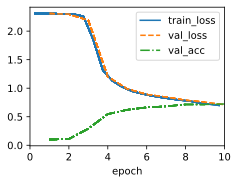

In [37]:
# LeNet Training

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)